# Week 2 - Commit 1
## Feature Engineering: Tenure & Monthly Charges Features

### Objective
To create new features from customer tenure and monthly charges that can improve churn prediction performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [4]:
df['Tenure_Group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=[
        'New Customer',
        'Regular Customer',
        'Loyal Customer',
        'Long-Term Customer'
    ]
)

df[['tenure', 'Tenure_Group']].head()

,tenure,Tenure_Group
0,1,New Customer
1,34,Loyal Customer
2,2,New Customer
3,45,Loyal Customer
4,2,New Customer


In [5]:
df['MonthlyCharge_Category'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 35, 70, 120],
    labels=['Low', 'Medium', 'High']
)

df[['MonthlyCharges', 'MonthlyCharge_Category']].head()

,MonthlyCharges,MonthlyCharge_Category
0,29.85,Low
1,56.95,Medium
2,53.85,Medium
3,42.30,Medium
4,70.70,High


In [6]:
df['Tenure_Group'].value_counts()

Tenure_Group
Long-Term Customer    2239
New Customer          2175
Loyal Customer        1594
Regular Customer      1024
Name: count, dtype: int64

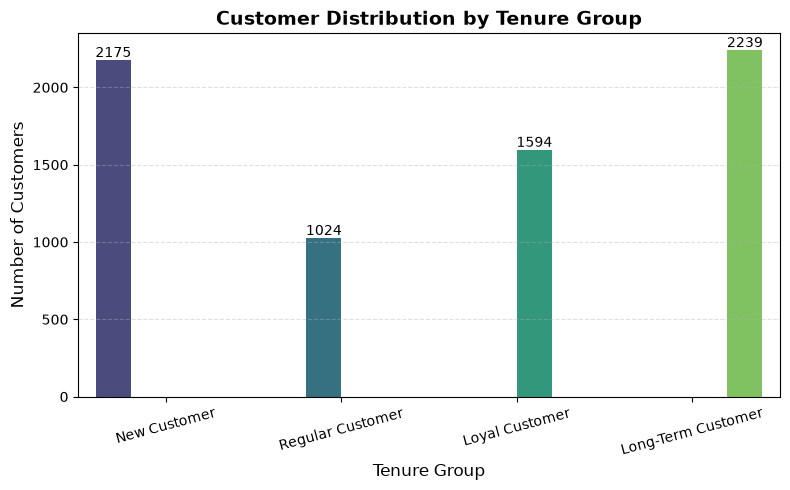

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import os



plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Tenure_Group',
    data=df,
    hue='Tenure_Group',
    palette='viridis',
    legend=False
)

plt.title('Customer Distribution by Tenure Group',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Tenure Group', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Add values on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()



plt.show()



In [9]:
df['MonthlyCharge_Category'].value_counts()

MonthlyCharge_Category
High      3583
Low       1735
Medium    1725
Name: count, dtype: int64

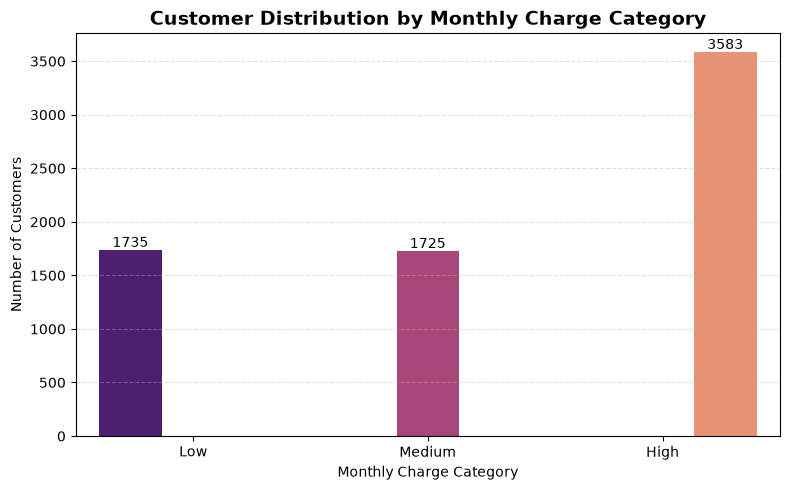

In [10]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='MonthlyCharge_Category',
    data=df,
    hue='MonthlyCharge_Category',
    palette='magma',
    legend=False
)

plt.title('Customer Distribution by Monthly Charge Category',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Monthly Charge Category')
plt.ylabel('Number of Customers')

plt.grid(axis='y', linestyle='--', alpha=0.4)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()



plt.show()



## Conclusion

Successfully created tenure-based and monthly charge-based features. These engineered features will be used in subsequent predictive modeling tasks such as Logistic Regression, Random Forest, and XGBoost.

# Week 2 - Commit 2

# Advanced Feature Engineering

## Objective

To create advanced customer behavior features such as Customer Engagement Level, Total Services, and Internet Service indicators that improve churn prediction and customer segmentation.


In [11]:
service_columns = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['TotalServices'] = (
    df[service_columns]
    .replace({'Yes':1, 'No':0, 'No internet service':0, 'No phone service':0})
    .sum(axis=1)
)

print("TotalServices feature created")

TotalServices feature created


In [12]:
df['InternetServiceFlag'] = df['InternetService'].apply(
    lambda x: 0 if x == 'No' else 1
)

print("InternetServiceFlag created")

InternetServiceFlag created


In [13]:
df['SecuritySupport'] = (
    (df['OnlineSecurity'] == 'Yes') &
    (df['TechSupport'] == 'Yes')
).astype(int)

print("SecuritySupport feature created")

SecuritySupport feature created


In [14]:
print(df[['TotalServices',
          'InternetServiceFlag',
          'SecuritySupport']].head())

  TotalServices  InternetServiceFlag  SecuritySupport
0             1                    1                0
1             3                    1                0
2             3                    1                0
3             3                    1                1
4             1                    1                0


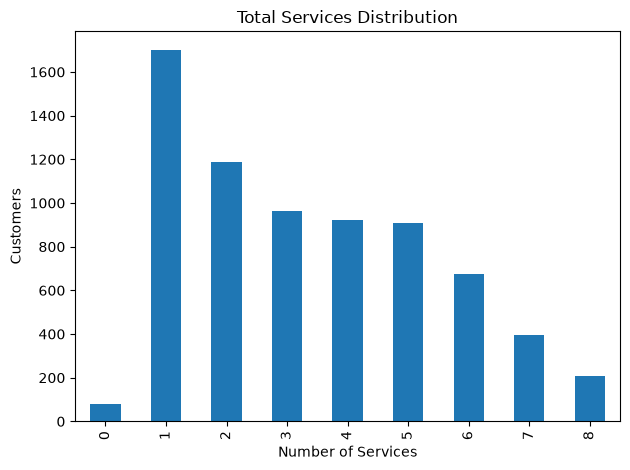

In [15]:
import matplotlib.pyplot as plt

df['TotalServices'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title("Total Services Distribution")
plt.xlabel("Number of Services")
plt.ylabel("Customers")
plt.tight_layout()

plt.savefig("../screenshots/week2_commit2_total_services_distribution.png")
plt.show()

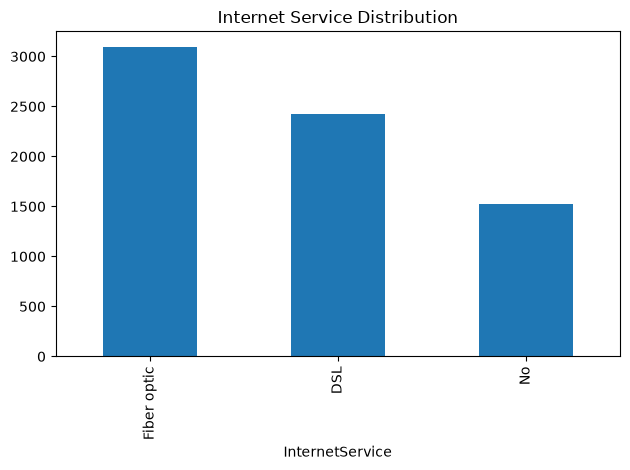

In [16]:
df['InternetService'].value_counts().plot(
    kind='bar'
)

plt.title("Internet Service Distribution")
plt.tight_layout()

plt.savefig("../screenshots/week2_commit2_internet_service_distribution.png")
plt.show()

In [18]:
df['PremiumCustomerScore'] = (
    (df['MonthlyCharges'] > df['MonthlyCharges'].median()) &
    (df['TotalServices'] >= 4)
).astype(int)

print("PremiumCustomerScore created")

PremiumCustomerScore created


In [20]:
df['SecurityAwarenessScore'] = (
    (df['OnlineSecurity'] == 'Yes').astype(int) +
    (df['OnlineBackup'] == 'Yes').astype(int) +
    (df['DeviceProtection'] == 'Yes').astype(int)
)

print("SecurityAwarenessScore created")

SecurityAwarenessScore created


In [21]:
df['EntertainmentScore'] = (
    (df['StreamingTV'] == 'Yes').astype(int) +
    (df['StreamingMovies'] == 'Yes').astype(int)
)

print("EntertainmentScore created")

EntertainmentScore created


In [24]:
service_columns = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['ServiceAdoptionScore'] = (
    df[service_columns]
    .replace({
        'Yes': 1,
        'No': 0,
        'No internet service': 0,
        'No phone service': 0
    })
    .sum(axis=1)
)

print("ServiceAdoptionScore created")

ServiceAdoptionScore created


In [25]:
def engagement(score):
    if score <= 2:
        return "Low"
    elif score <= 5:
        return "Medium"
    else:
        return "High"

df["CustomerEngagementLevel"] = df["ServiceAdoptionScore"].apply(engagement)

print("CustomerEngagementLevel created")

CustomerEngagementLevel created


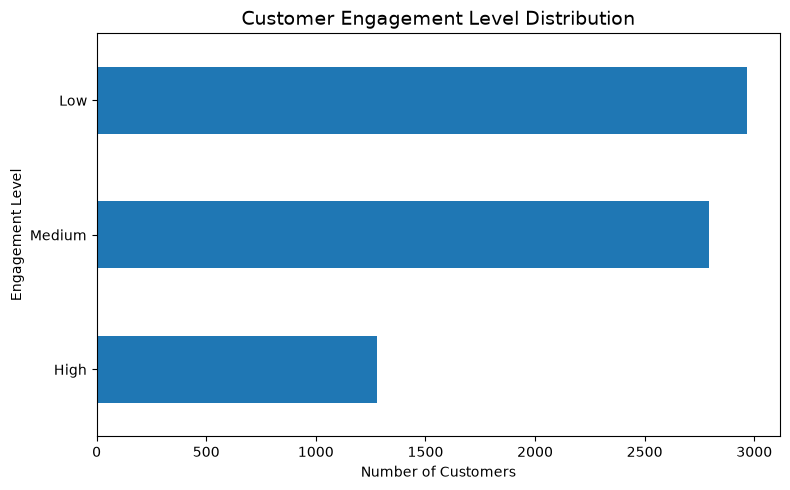

In [28]:
import matplotlib.pyplot as plt

engagement_counts = df['CustomerEngagementLevel'].value_counts()

plt.figure(figsize=(8,5))
engagement_counts.sort_values().plot(kind='barh')

plt.title('Customer Engagement Level Distribution', fontsize=14)
plt.xlabel('Number of Customers')
plt.ylabel('Engagement Level')

plt.tight_layout()
plt.savefig('../screenshots/week2_commit2_customer_engagement_barh.png')
plt.show()

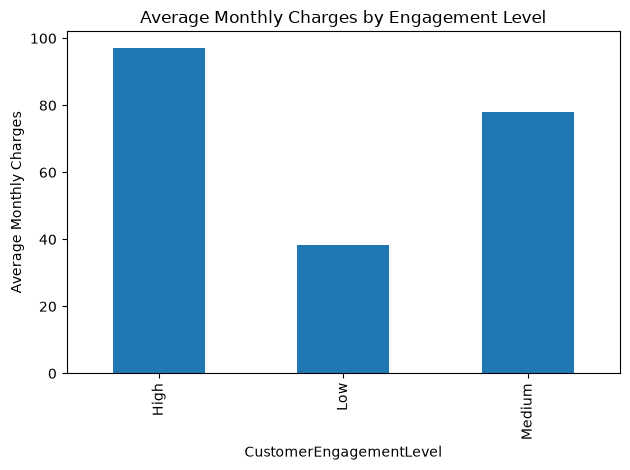

In [29]:
df.groupby('CustomerEngagementLevel')['MonthlyCharges'].mean().plot(
    kind='bar'
)

plt.title("Average Monthly Charges by Engagement Level")
plt.ylabel("Average Monthly Charges")

plt.tight_layout()

plt.savefig("../screenshots/week2_commit2_engagement_vs_charges.png")
plt.show()

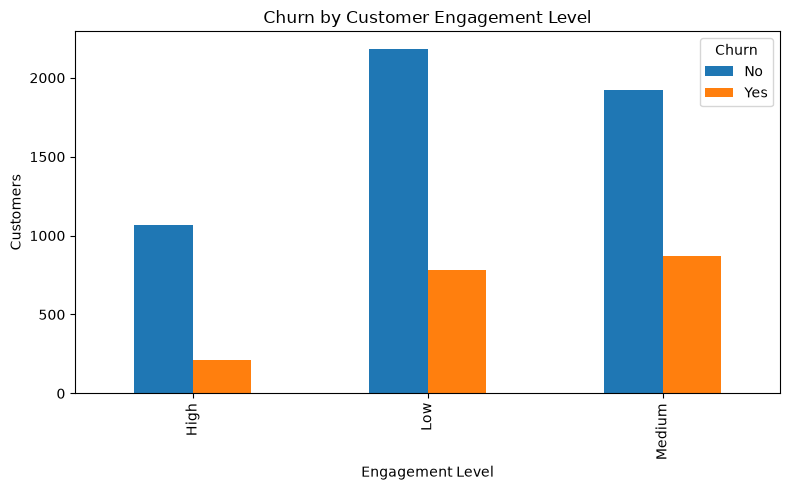

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

pd.crosstab(
    df['CustomerEngagementLevel'],
    df['Churn']
).plot(kind='bar', figsize=(8,5))

plt.title('Churn by Customer Engagement Level')
plt.xlabel('Engagement Level')
plt.ylabel('Customers')

plt.tight_layout()
plt.savefig('../screenshots/week2_commit2_churn_vs_engagement.png')
plt.show()

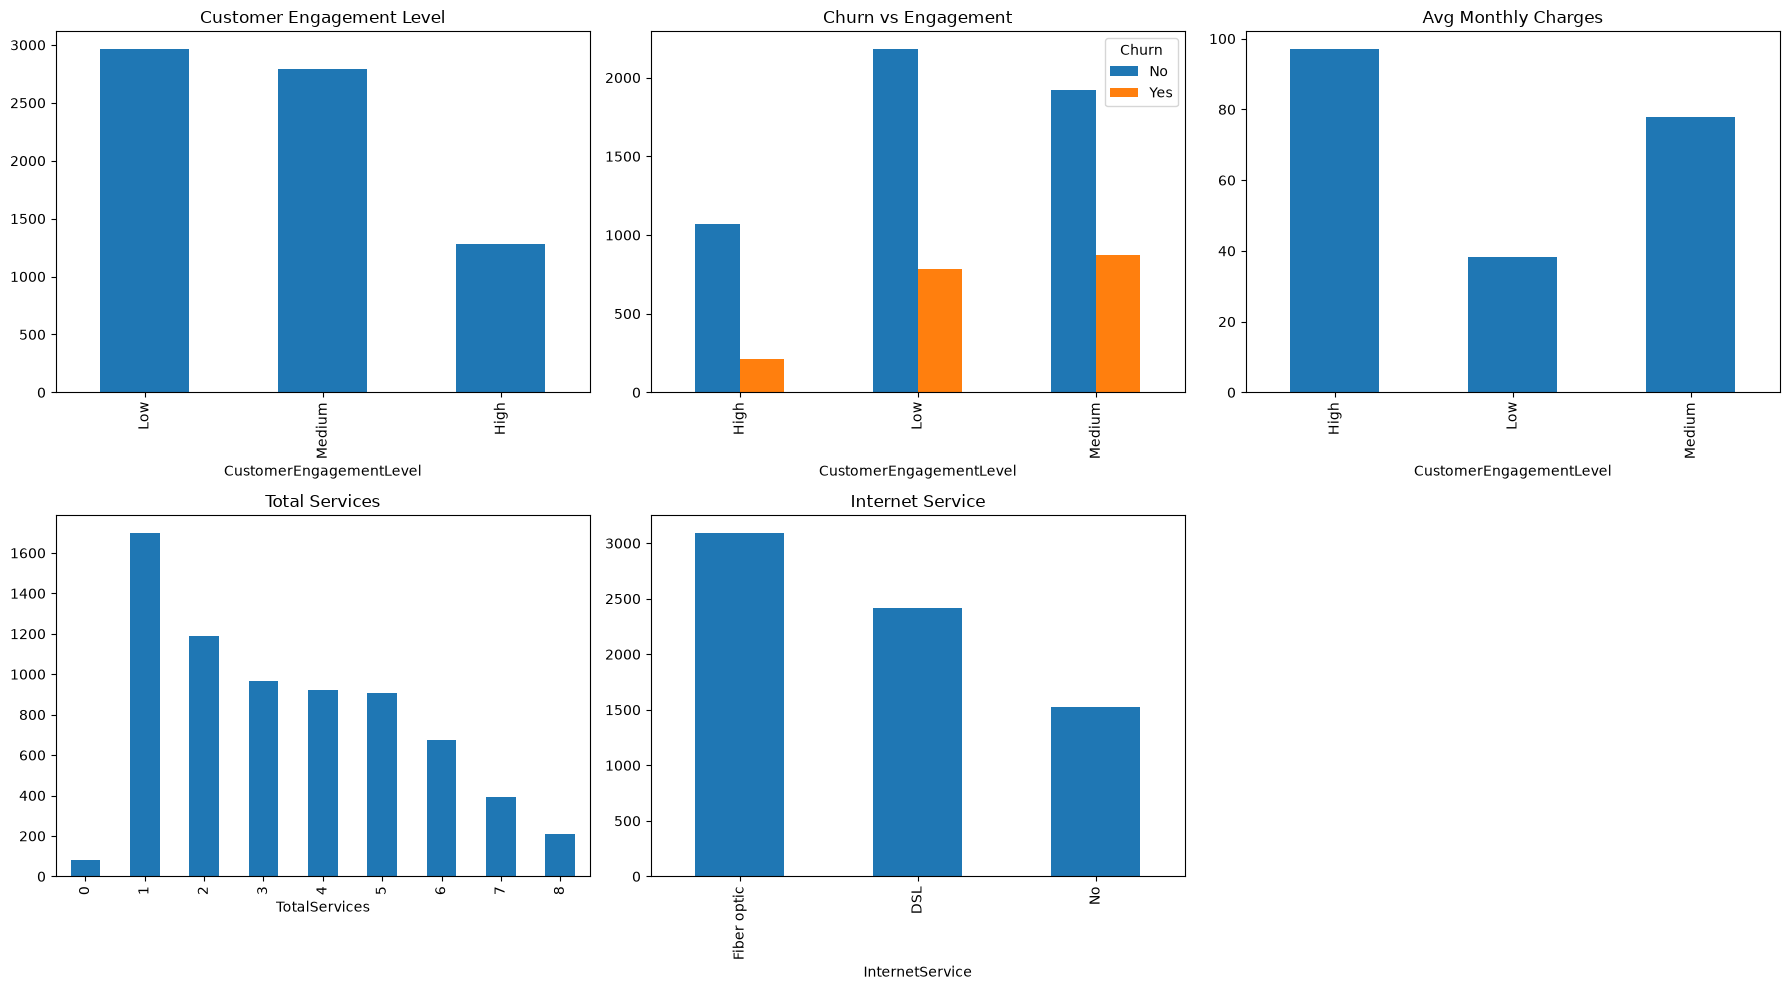

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(18,10))

# Graph 1
plt.subplot(2,3,1)
df['CustomerEngagementLevel'].value_counts().plot(kind='bar')
plt.title('Customer Engagement Level')

# Graph 2
plt.subplot(2,3,2)
pd.crosstab(
    df['CustomerEngagementLevel'],
    df['Churn']
).plot(kind='bar', ax=plt.gca())
plt.title('Churn vs Engagement')

# Graph 3
plt.subplot(2,3,3)
df.groupby('CustomerEngagementLevel')['MonthlyCharges'].mean().plot(kind='bar')
plt.title('Avg Monthly Charges')

# Graph 4
plt.subplot(2,3,4)
df['TotalServices'].value_counts().sort_index().plot(kind='bar')
plt.title('Total Services')

# Graph 5
plt.subplot(2,3,5)
df['InternetService'].value_counts().plot(kind='bar')
plt.title('Internet Service')

plt.tight_layout()

plt.savefig("../screenshots/week2_commit2_dashboard.png")
plt.show()

In [32]:
df.to_csv(
    "../data/telco_feature_engineered_commit2.csv",
    index=False
)

print("Feature engineered dataset saved successfully")

Feature engineered dataset saved successfully


## Conclusion

Advanced feature engineering was successfully completed by creating meaningful customer behavior features such as Customer Engagement Level and Total Services. These new features provide deeper insights into customer engagement patterns and service usage, helping improve the performance and interpretability of future churn prediction models.

# Week 2 Day 3 - Customer Behavior Feature Engineering

## Objective
Create customer behavior-based features to identify premium, long-term, and high-value customers and analyze contract-related churn risk.

In [2]:
import pandas as pd

df = pd.read_csv("../data/telco_feature_engineered_commit2.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Tenure_Group,MonthlyCharge_Category,TotalServices,InternetServiceFlag,SecuritySupport,PremiumCustomerScore,SecurityAwarenessScore,EntertainmentScore,ServiceAdoptionScore,CustomerEngagementLevel
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,New Customer,Low,1,1,0,0,1,0,1,Low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Loyal Customer,Medium,3,1,0,0,2,0,3,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,New Customer,Medium,3,1,0,0,2,0,3,Medium
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Loyal Customer,Medium,3,1,1,0,2,0,3,Medium
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,New Customer,High,1,1,0,0,0,0,1,Low


In [4]:
df['PremiumCustomerScore'] = (
    (df['MonthlyCharges'] > df['MonthlyCharges'].median()) &
    (df['TotalServices'] >= 4)
).astype(int)

In [5]:
df['LongTermCustomer'] = (
    df['tenure'] >= 24
).astype(int)

In [6]:
df['HighValueCustomer'] = (
    (df['MonthlyCharges'] > 70) &
    (df['tenure'] > 12)
).astype(int)

In [7]:
def contract_risk(contract):
    if contract == "Month-to-month":
        return "High Risk"
    elif contract == "One year":
        return "Medium Risk"
    else:
        return "Low Risk"

df['ContractRiskLevel'] = df['Contract'].apply(contract_risk)

In [8]:
print("High Value Customer")
print(df['HighValueCustomer'].value_counts())

print("\nContract Risk Level")
print(df['ContractRiskLevel'].value_counts())

print("\nLong Term Customer")
print(df['LongTermCustomer'].value_counts())

High Value Customer
HighValueCustomer
0    4335
1    2708
Name: count, dtype: int64

Contract Risk Level
ContractRiskLevel
High Risk      3875
Low Risk       1695
Medium Risk    1473
Name: count, dtype: int64

Long Term Customer
LongTermCustomer
1    3927
0    3116
Name: count, dtype: int64


In [9]:
print("\nPremium Customer Score")
print(df['PremiumCustomerScore'].value_counts())


Premium Customer Score
PremiumCustomerScore
0    4549
1    2494
Name: count, dtype: int64


In [10]:
df[['PremiumCustomerScore',
    'HighValueCustomer',
    'LongTermCustomer',
    'ContractRiskLevel']].head(10)

,PremiumCustomerScore,HighValueCustomer,LongTermCustomer,ContractRiskLevel
0,0,0,0,High Risk
1,0,0,1,Medium Risk
2,0,0,0,High Risk
3,0,0,1,Medium Risk
4,0,0,0,High Risk
5,1,0,0,High Risk
6,1,1,0,High Risk
7,0,0,0,High Risk
8,1,1,1,High Risk
9,0,0,1,Medium Risk


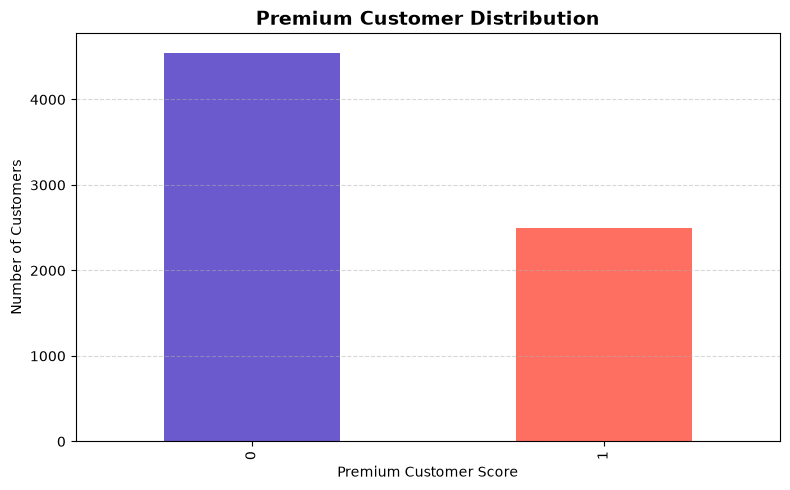

In [11]:
import matplotlib.pyplot as plt

premium_counts = df['PremiumCustomerScore'].value_counts()

plt.figure(figsize=(8,5))
premium_counts.plot(
    kind='bar',
    color=['#6A5ACD', '#FF6F61']
)

plt.title('Premium Customer Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Premium Customer Score')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(
    '../screenshots/week2_commit3_premium_customer_distribution.png'
)
plt.show()

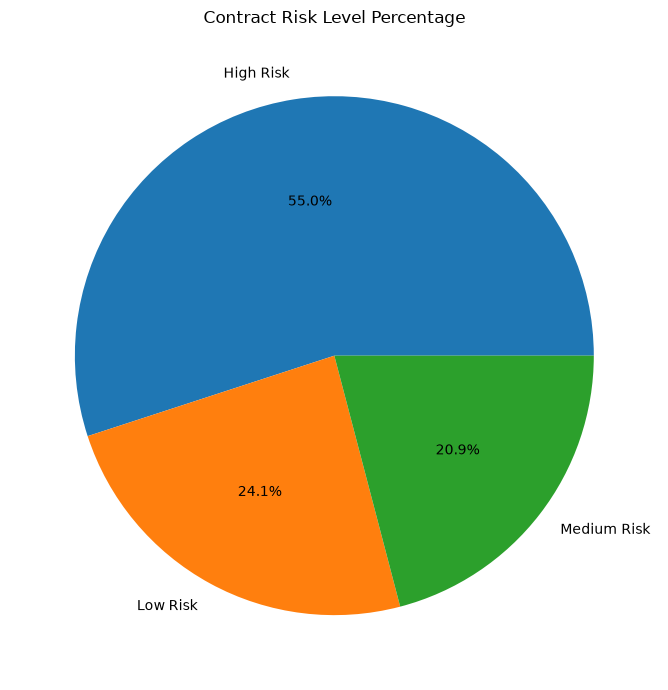

In [12]:
plt.figure(figsize=(7,7))
df['ContractRiskLevel'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Contract Risk Level Percentage')
plt.ylabel('')
plt.tight_layout()
plt.savefig(
    '../screenshots/week2_commit3_contract_risk_pie.png'
)
plt.show()

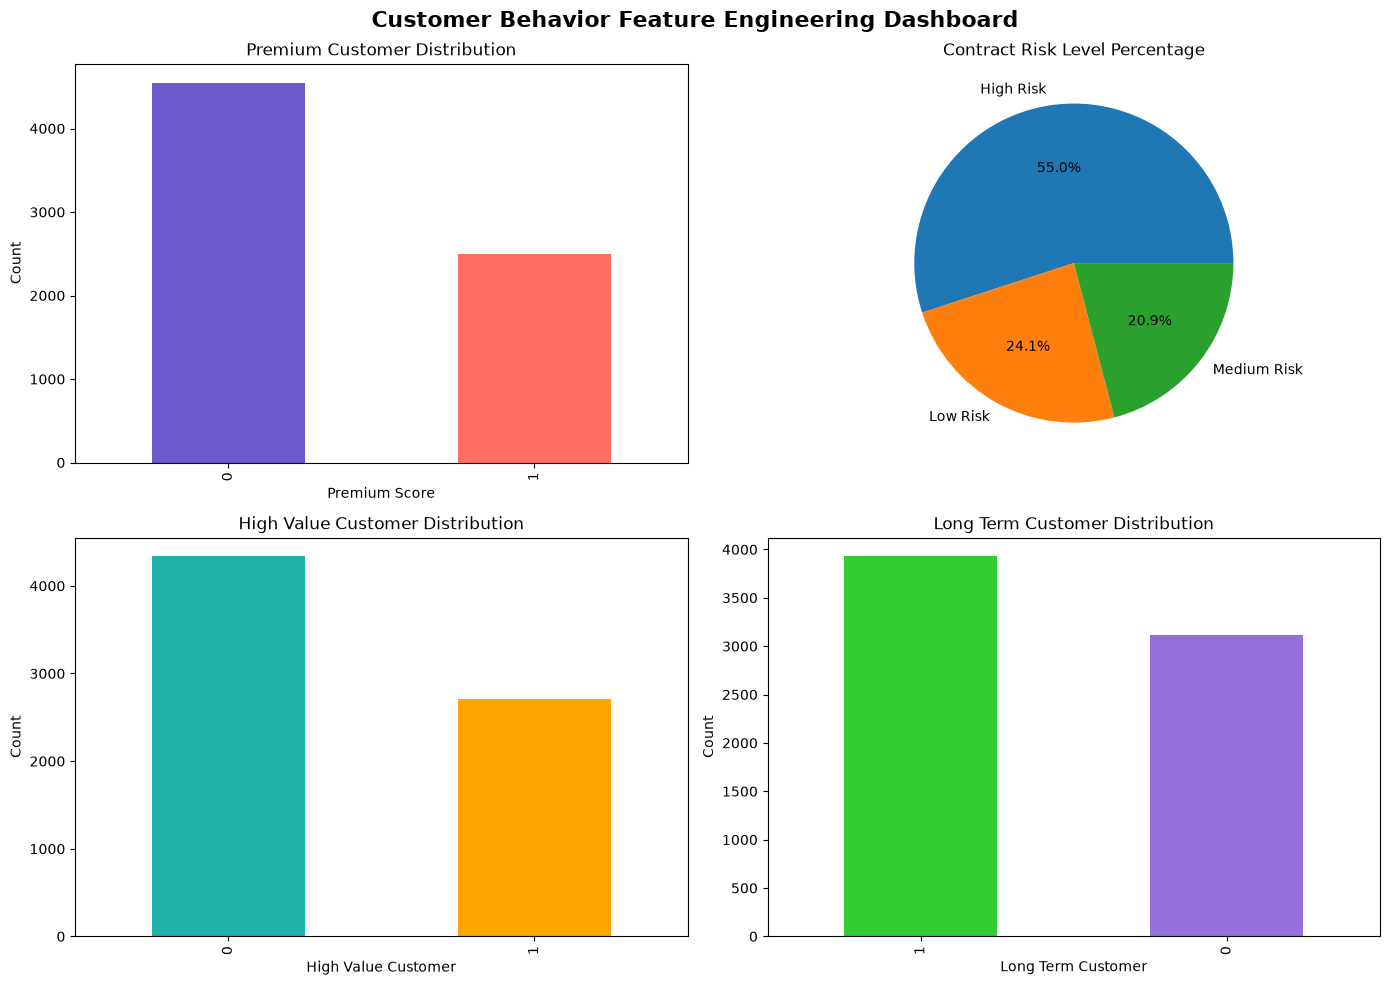

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Premium Customer Distribution (Bar Chart)
df['PremiumCustomerScore'].value_counts().plot(
    kind='bar',
    ax=axes[0,0],
    color=['#6A5ACD','#FF6F61']
)
axes[0,0].set_title('Premium Customer Distribution')
axes[0,0].set_xlabel('Premium Score')
axes[0,0].set_ylabel('Count')

# 2. Contract Risk Level Percentage (Pie Chart)
df['ContractRiskLevel'].value_counts().plot(
    kind='pie',
    ax=axes[0,1],
    autopct='%1.1f%%'
)
axes[0,1].set_title('Contract Risk Level Percentage')
axes[0,1].set_ylabel('')

# 3. High Value Customer Distribution (Bar Chart)
df['HighValueCustomer'].value_counts().plot(
    kind='bar',
    ax=axes[1,0],
    color=['#20B2AA','#FFA500']
)
axes[1,0].set_title('High Value Customer Distribution')
axes[1,0].set_xlabel('High Value Customer')
axes[1,0].set_ylabel('Count')

# 4. Long Term Customer Distribution (Bar Chart)
df['LongTermCustomer'].value_counts().plot(
    kind='bar',
    ax=axes[1,1],
    color=['#32CD32','#9370DB']
)
axes[1,1].set_title('Long Term Customer Distribution')
axes[1,1].set_xlabel('Long Term Customer')
axes[1,1].set_ylabel('Count')

plt.suptitle(
    'Customer Behavior Feature Engineering Dashboard',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('../screenshots/week2_commit3_dashboard.png')
plt.show()

In [15]:
df.to_csv(
    "../data/telco_feature_engineered_commit3.csv",
    index=False
)

## Conclusion

Customer behavior-based feature engineering was successfully completed on the Telco Customer Churn dataset. New features including PremiumCustomerScore, HighValueCustomer, LongTermCustomer, and ContractRiskLevel were created to capture customer value, loyalty, and risk patterns. The dashboard visualizations provided meaningful insights into customer segments and contract-related behavior. These engineered features enhance the dataset and provide a stronger foundation for customer churn prediction and business decision-making in the next phase of the project.

# Week 2 Day 4 - Logistic Regression Model Training

## Objective

The objective of this task is to train a Logistic Regression model using the feature-engineered Telco Customer Churn dataset. The model will be used to predict customer churn based on customer attributes and engineered features.

### Goals

- Prepare the feature-engineered dataset for machine learning.
- Define the target variable for customer churn prediction.
- Split the dataset into training and testing sets.
- Train a Logistic Regression classification model.
- Generate churn predictions for the test data.
- Establish a baseline model for customer churn prediction.

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders available:")
print(os.listdir())

Current working directory:
c:\Users\Afreen\OneDrive\Desktop\zaalima-data-analytic\scripts

Files/folders available:
['data_loader.py', 'feature_engineering.ipynb']


In [6]:
# Load the final feature-engineered dataset from Day 3
df = pd.read_csv("../data/telco_feature_engineered_commit3.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 34)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,InternetServiceFlag,SecuritySupport,PremiumCustomerScore,SecurityAwarenessScore,EntertainmentScore,ServiceAdoptionScore,CustomerEngagementLevel,LongTermCustomer,HighValueCustomer,ContractRiskLevel
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,1,0,0,1,0,1,Low,0,0,High Risk
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,1,0,0,2,0,3,Medium,1,0,Medium Risk
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,1,0,0,2,0,3,Medium,0,0,High Risk
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,1,1,0,2,0,3,Medium,1,0,Medium Risk
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,1,0,0,0,0,1,Low,0,0,High Risk


In [7]:
# Check the target variable
print("Churn value counts:")
print(df["Churn"].value_counts())

print("\nChurn data types:")
print(df["Churn"].dtype)

Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn data types:
str


In [8]:
# Convert Churn into a binary target variable
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

print("Churn values after encoding:")
print(df["Churn"].value_counts())

Churn values after encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [9]:
# Separate features and target variable

X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 33)
Target shape: (7043,)


In [10]:
# Identify categorical and numerical features

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumber of categorical columns:", len(categorical_cols))
print("Number of numerical columns:", len(numerical_cols))

Categorical columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Tenure_Group', 'MonthlyCharge_Category', 'CustomerEngagementLevel', 'ContractRiskLevel']

Number of categorical columns: 21
Number of numerical columns: 12


C:\Users\Afreen\AppData\Local\Temp\ipykernel_16060\1582259082.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Create preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [12]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5634, 33)
Testing features: (1409, 33)
Training target: (5634,)
Testing target: (1409,)


In [13]:
# Apply preprocessing to training and testing data

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (5634, 10977)
Processed testing data shape: (1409, 10977)


In [14]:
# Train Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [15]:
# Generate predictions on the test data

y_pred = logistic_model.predict(X_test_processed)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 1409


In [16]:
# Calculate Logistic Regression accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", round(accuracy, 4))
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

Logistic Regression Accuracy: 0.7949
Accuracy Percentage: 79.49 %


In [17]:
# Generate classification report

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [18]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Logistic Regression Confusion Matrix:")
print(cm)

Logistic Regression Confusion Matrix:
[[929 106]
 [183 191]]


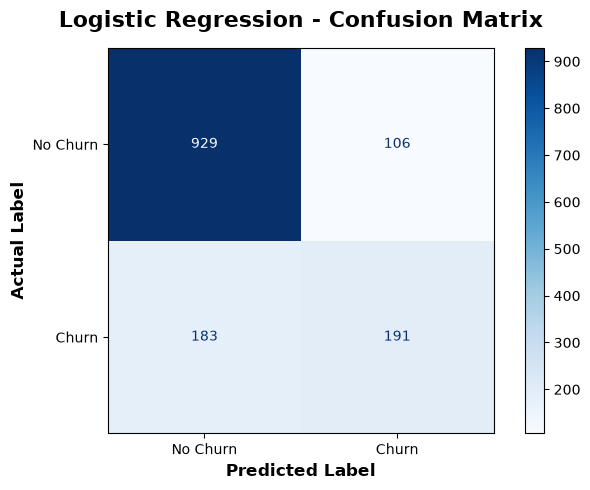

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Plot professional confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

ax.set_title(
    "Logistic Regression - Confusion Matrix",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Predicted Label", fontsize=12, fontweight="bold")
ax.set_ylabel("Actual Label", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(
    '../screenshots/week2_commit4_Confusion Matrix.png')
plt.show()

In [20]:
import joblib

# Save the trained Logistic Regression model
joblib.dump(logistic_model, "../data/logistic_regression_model.pkl")

print("Logistic Regression model saved successfully.")

Logistic Regression model saved successfully.


In [21]:
# Save the preprocessing pipeline
joblib.dump(preprocessor, "../data/logistic_regression_preprocessor.pkl")

print("Preprocessing pipeline saved successfully.")

Preprocessing pipeline saved successfully.


## Conclusion

The Logistic Regression model was successfully trained using the feature-engineered Telco Customer Churn dataset. After preprocessing the categorical and numerical features, the model achieved an accuracy of **79.49%** on the test dataset. The classification report and confusion matrix provided insights into the model's performance in predicting customer churn. The trained model and preprocessing pipeline were also saved for future use and evaluation.



